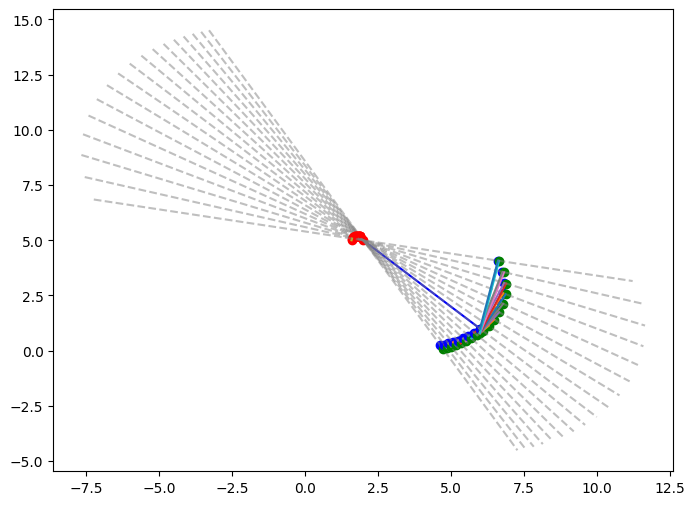

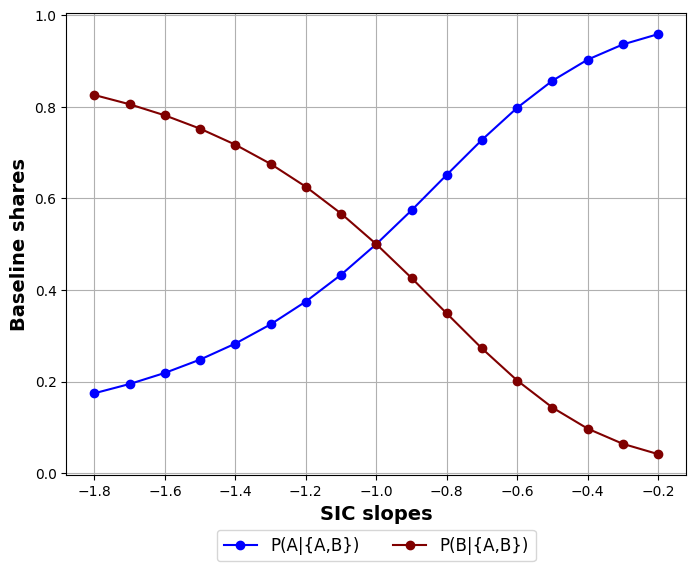

In [1]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np
beta = 1
def softmax(x):
    e_x = np.exp((x - np.max(x)) * beta)
    return e_x / e_x.sum()

def perpendicular_foot(Px, Py, Ox, Oy, m): # Foot of the perpendicular from point P to line with slope m and passing through O
    Px_, Py_ = sp.symbols('Px_ Py_')
    
    eq1 = sp.Eq(Py - Py_, (-1/m) * (Px - Px_))
    eq2 = sp.Eq(Oy - Py_, m * (Ox - Px_))
    
    solution = sp.solve((eq1, eq2), (Px_, Py_))
    
    return float(solution[Px_]), float(solution[Py_])

def signed_l(Ax,Ay,Bx,By):
    # Calculate the distance between the points
    l = np.sqrt((Ax - Bx)**2 + (Ay - By)**2)

    # Calculate the signed length based on the formula
    if (Ax - Bx) != 0:
        signed_l = l * (Ax - Bx) / np.abs(Ax - Bx)
    else:
        signed_l = 0
    return signed_l



# Given points
Ax, Ay = 2, 5
Bx, By = 6, 1
# Calculate Me (slope of AB the Experimenter Defined Indifference Curve)
Me = (Ay - By) / (Ax - Bx)
# List of Mi values
#Mi_values = [-0.5, -1.5, -1.2,-1]
Mi_values = np.arange(Me - 0.8, Me + 0.81, 0.1)
# Set up the plot
plt.figure(figsize=(8, 6))

# Plotting
plt.plot(Ax, Ay, 'ro', label='A (2, 5)')
plt.plot(Bx, By, 'go', label='B (6, 1)')
D1x,D1y = 0.8*Ax, Ay # Range Decoy targeting A
D2x,D2y = Bx, 0.8*By # Range Decoy targeting B
D11x,D11y = Bx+ 0.2*Ax, By

plt.plot(D1x,D1y, 'ro', label='D1')
plt.plot(D2x,D2y, 'go', label='D2')

plt.plot([Ax, Bx], [Ay, By], 'b', label='AB')
p_A_baseline_values = []
P_c1_choice_values = []
P_c2_choice_values = []
ast_t_values = []
ast_c_values = []
rst_ew_values = []
rst_uw_values = []
del_p_a_values = []
del_p_b_values = []

for Mi in Mi_values:
    Bx_, By_ = perpendicular_foot(Bx, By, Ax, Ay, Mi)
    plt.plot(Bx_, By_, 'bo' )
    d = signed_l(Bx,By,Bx_,By_)
    # Calculate the softmax-transformed value of d
    baseline = softmax([0, d])
    p_A_baseline_values.append(baseline[0])
    
    D1x_,D1y_ = perpendicular_foot(D1x, D1y, Ax, Ay, Mi)
    d1 = signed_l(D1x,D1y,D1x_,D1y_)
    plt.plot(D1x_,D1y_, 'ro' )
    plt.plot([D1x, D1x_], [D1y, D1y_] )   
    
    D2x_,D2y_ = perpendicular_foot(D2x, D2y, Ax, Ay, Mi)
    d2 = signed_l(D2x,D2y,D2x_,D2y_)
    plt.plot(D2x_,D2y_, 'go')
    plt.plot([D2x, D2x_], [D2y, D2y_])
    
    if D2y <= Ay-Mi*(Ax-Bx) <= By: #SIC through A pssing between B & D2
        beta = 1               # clear dominance is perceived between B & D2
        choice_c1 = softmax([0, d, d1]) # in context {A,B,D2} & in {A,B,D1} A& D1 lie
        choice_c2 = softmax([0, d, d2]) # lie same side of SIC passing through B, treated similar and reversed attraction
        beta = 1 # reset beta
    elif Bx <= Ax - (Ay-By)*1/Mi <= D11x:
        beta =1
        choice_c1 = softmax([0, d, d1])
        choice_c2 = softmax([0, d, d2])
        beta = 1
    else:
        choice_c1 = softmax([0, d, d1])
        choice_c2 = softmax([0, d, d2]) 
        
         # Plot Line BB' for each Mi value
    plt.plot([Bx, Bx_], [By, By_])
        
    # Extend lines
    ext_factor = 2
    ext_Ax1 = Ax - ext_factor * (Bx_ - Ax)
    ext_Ay1 = Ay - ext_factor * (By_ - Ay)
    ext_Ax2 = Ax + ext_factor * (Bx_ - Ax)
    ext_Ay2 = Ay + ext_factor * (By_ - Ay)

    # Directly plot the extended lines passing through point A
    plt.plot([ext_Ax1, ext_Ax2], [ext_Ay1, ext_Ay2], linestyle='dashed', color='gray', alpha=0.5)

# Create a plot for Baseline Shares vs SIC
plt.figure(figsize=(8, 6))
p_B_baseline = [1 - value for value in p_A_baseline_values]
plt.plot(Mi_values, p_A_baseline_values,  marker='o', color='blue', label='P(A|{A,B})')
plt.plot(Mi_values, p_B_baseline, marker='o', color='maroon', label='P(B|{A,B})')

plt.xlabel('SIC slopes', fontsize=14, weight='bold')
plt.ylabel('Baseline shares', fontsize=14, weight='bold')
# plt.title('Baseline shares vs. SIC slopes')
# Legend settings
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),ncol = 2, fontsize=12)
plt.grid(True)
plt.show()